# LAB 5
### Chirag Rao K V
### 240962180
### AIML B 16

In [483]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.linear_model import LinearRegression, LogisticRegression

In [484]:
data = {"mother_height":[58,62,60,64,67,70],
        "daughter_height":[60,60,58,60,70,72]
        }
data = pd.DataFrame(data)
data

,mother_height,daughter_height
0,58,60
1,62,60
2,60,58
3,64,60
4,67,70
5,70,72


100%|██████████| 1000/1000 [00:00<00:00, 19177.82it/s]


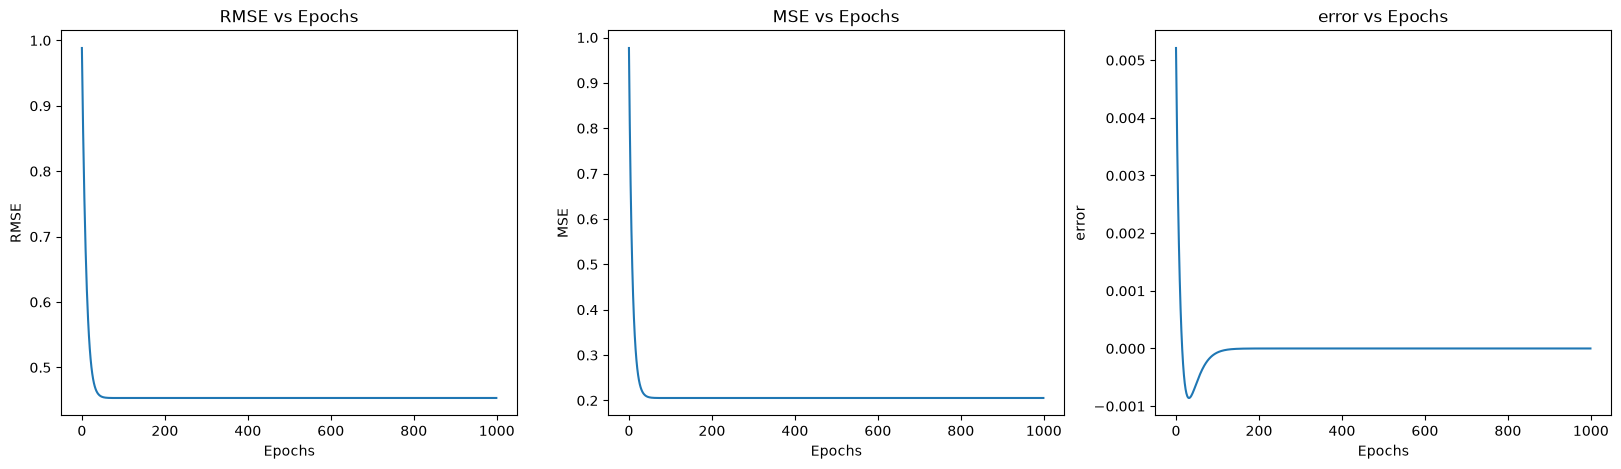

In [485]:
class Simple_LR:
    def __init__(self, x, y):
        self.x = np.asarray(x)
        self.y = np.asarray(y)

        if self.x.ndim == 1:
            self.x = self.x.reshape(-1, 1)

        self.weights = np.zeros(self.x.shape[1])
        self.bias = 0

    def predict(self,x):
        return x * self.weights + self.bias

    def train(self,no_epoch,alpha,norm_y=True):
        self.x = (self.x-np.mean(self.x,axis=0))/np.std(self.x,axis=0)
        if(norm_y):
            self.y = (self.y-np.mean(self.y))/np.std(self.y)
        self.rmse = []
        self.mean_error = []
        y_pred = np.zeros_like(self.y)
        loss_ = []
        for i in tqdm(range(no_epoch)):
            epoch_error = []
            for j in range(len(self.x)):
                y_pred[j] = np.dot(self.x[j], self.weights) + self.bias
                error = self.y[j] - y_pred[j]
                dw = -self.x[j] * error
                db = -error
                self.weights = self.weights - alpha * dw
                self.bias = self.bias - alpha * db
                epoch_error.append(error)
            self.rmse.append(np.sqrt(np.mean(np.array(epoch_error)**2)))
            self.mean_error.append(np.mean(np.array(epoch_error)**2))
            loss_.append(np.mean(epoch_error))
        
        fig, ax = plt.subplots(1, 3, figsize=(20, 5))
        ax[0].plot(self.rmse)
        ax[0].set_xlabel("Epochs")
        ax[0].set_ylabel("RMSE")
        ax[0].set_title("RMSE vs Epochs")
        ax[1].plot(self.mean_error)
        ax[1].set_xlabel("Epochs")
        ax[1].set_ylabel("MSE")
        ax[1].set_title("MSE vs Epochs")
        plt.plot(loss_)
        ax[2].set_xlabel("Epochs")
        ax[2].set_ylabel("error")
        ax[2].set_title("error vs Epochs")
        plt.show()

LR = Simple_LR(data['mother_height'].to_numpy(),data['daughter_height'].to_numpy())
LR.train(1000,0.01)
# LR.plot_data()|

100%|██████████| 1000/1000 [00:00<00:00, 17319.38it/s]


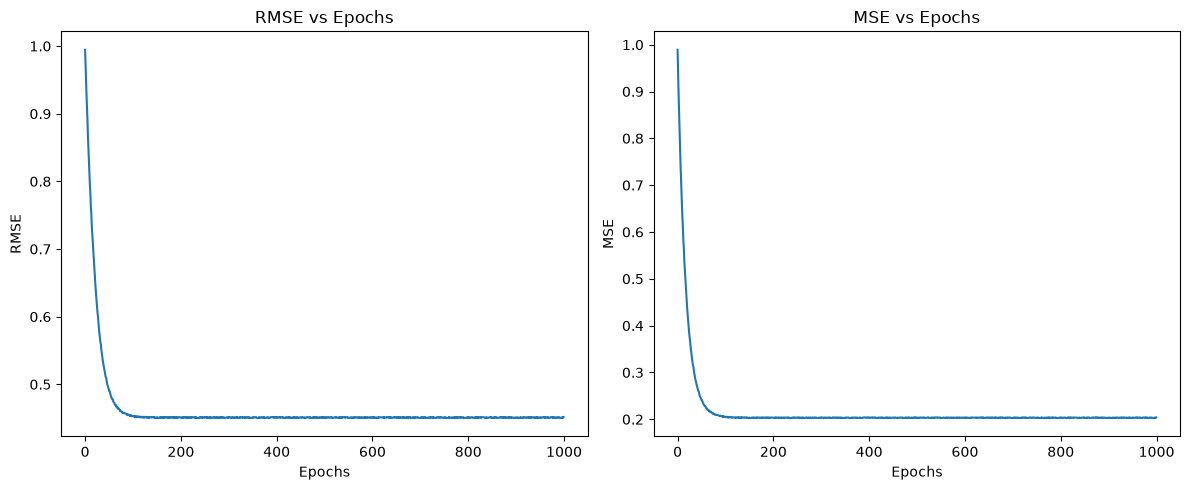

In [486]:
class Simple_LR_batch:
    def __init__(self, x, y):
        self.x = np.asarray(x)
        self.y = np.asarray(y)

        if self.x.ndim == 1:
            self.x = self.x.reshape(-1, 1)

        self.weights = np.zeros(self.x.shape[1])
        self.bias = 0

    def predict(self,x):
        return x * self.weights + self.bias

    def train(self, no_epoch, alpha, batch_size, norm_y=True):
        self.x = (self.x - np.mean(self.x, axis=0)) / np.std(self.x, axis=0)
        if norm_y:
            self.y = (self.y - np.mean(self.y)) / np.std(self.y)
        self.rmse = []
        self.mean_error = []
        n = len(self.x)
        for i in tqdm(range(no_epoch)):
            indices = np.random.permutation(n)
            x_shuffled = self.x[indices]
            y_shuffled = self.y[indices]
            epoch_error = []
            for start in range(0, n, batch_size):
                end = start + batch_size
                x_batch = x_shuffled[start:end]
                y_batch = y_shuffled[start:end]
                y_pred = x_batch @ self.weights + self.bias
                error = y_pred - y_batch
                dw = (x_batch.T @ error) / len(x_batch)
                db = np.mean(error)
                self.weights -= alpha * dw
                self.bias -= alpha * db
                epoch_error.extend(error)
            epoch_error = np.array(epoch_error)
            self.rmse.append(np.sqrt(np.mean(epoch_error ** 2)))
            self.mean_error.append(np.mean(epoch_error ** 2))
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))

        ax[0].plot(self.rmse)
        ax[0].set_xlabel("Epochs")
        ax[0].set_ylabel("RMSE")
        ax[0].set_title("RMSE vs Epochs")

        ax[1].plot(self.mean_error)
        ax[1].set_xlabel("Epochs")
        ax[1].set_ylabel("MSE")
        ax[1].set_title("MSE vs Epochs")
        plt.tight_layout()
        plt.show()

LRb = Simple_LR_batch(data['mother_height'].to_numpy(),data['daughter_height'].to_numpy())
LRb.train(1000,0.01,2)
# LR.plot_data()|

In [487]:
print(f"Predicted daughters height given mothers height is 63:{LR.predict(63)}")
print(f"Predicted daughters height given mothers height is 63:{LRb.predict(63)}")

Predicted daughters height given mothers height is 63:[56.59195861]
Predicted daughters height given mothers height is 63:[56.29510792]


In [488]:
# Original data
X = data['mother_height'].to_numpy()
y = data['daughter_height'].to_numpy()
X_norm = (X - np.mean(X)) / np.std(X)
y_norm = (y - np.mean(y)) / np.std(y)
X_norm = X_norm.reshape(-1, 1)
slr = LinearRegression()
slr.fit(X_norm, y_norm)
print(f"Predicted daughters height given mothers height is 63:{slr.predict([[63]])}")
print(f"{'Method':<30}|{'weights':<15} | {'bias':<15} | {'RMSE':<15} | {'MSE':<15}")
print("-" * 70)
print(f"{'SGD_custom':<30} | {LR.weights[0]:<15.6f} | {LR.bias:<15.6f}| {np.mean(LR.rmse):<15.6f} | {np.mean(LR.mean_error):<15.6f}")
print(f"{'BGD_custom':<30} | {LRb.weights[0]:<15.6f} | {LRb.bias:<15.6f}| {np.mean(LRb.rmse):<15.6f}| {np.mean(LRb.mean_error):<15.6f}")
print(f"{'SKlearn':<30} | {slr.coef_[0]:<15.6f} | {slr.intercept_:<15.6f}")

Predicted daughters height given mothers height is 63:[56.28224763]
Method                        |weights         | bias            | RMSE            | MSE            
----------------------------------------------------------------------
SGD_custom                     | 0.898291        | -0.000388      | 0.458816        | 0.212114       
BGD_custom                     | 0.893568        | 0.000325       | 0.462130       | 0.216724       
SKlearn                        | 0.893369        | -0.000000      


Q2

In [489]:
study = {"hours_study":[1,2,3,4,5,6,7,8],
         "Pass":[0,0,0,0,1,1,1,1]}
study_df = pd.DataFrame(study)

In [490]:
class LogiRegression:
    def __init__(self, x, y):
        self.x = np.asarray(x)
        self.y = np.asarray(y)
        if self.x.ndim == 1:
            self.x = self.x.reshape(-1, 1)
        self.weights = np.zeros(self.x.shape[1])
        self.bias = 0

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def cross_entropy_loss(self, pred, actual):
        epsilon = 1e-15
        pred = np.clip(pred, epsilon, 1 - epsilon)
        self.loss_ = -np.mean(actual * np.log(pred) +(1 - actual) * np.log(1 - pred))
        return self.loss_

    def predict(self, x):
        x = np.asarray(x)
        if x.ndim == 1:
            x = x.reshape(-1, 1)
        z = x @ self.weights + self.bias
        return self.sigmoid(z)

    def train(self, no_epoch, alpha):
        self.loss_train = []
        for i in tqdm(range(no_epoch)):
            epoch_pred = []
            for j in range(len(self.x)):
                z = np.dot(self.x[j], self.weights) + self.bias
                y_pred = self.sigmoid(z)
                error = y_pred - self.y[j]
                dw = self.x[j] * error
                db = error
                self.weights -= alpha * dw
                self.bias -= alpha * db
                epoch_pred.append(y_pred)
            epoch_pred = np.array(epoch_pred)
            loss = self.cross_entropy_loss(epoch_pred,self.y)

            self.loss_train.append(loss)

        plt.plot(self.loss_train)
        plt.xlabel("Epochs")
        plt.ylabel("Cross Entropy Loss")
        plt.title("Training Loss")
        plt.show()

100%|██████████| 10000/10000 [00:00<00:00, 15700.37it/s]


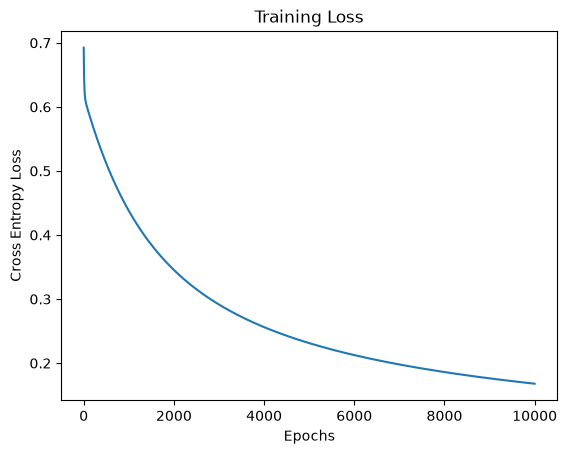

In [491]:
Log = LogiRegression(study_df["hours_study"],study_df["Pass"])
Log.train(10000, 0.001)

In [492]:
class LogiRegression_b:
    def __init__(self, x, y):
        self.x = np.asarray(x)
        self.y = np.asarray(y)
        if self.x.ndim == 1:
            self.x = self.x.reshape(-1, 1)
        self.weights = np.zeros(self.x.shape[1])
        self.bias = 0
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def cross_entropy_loss(self, pred, actual):
        epsilon = 1e-15
        pred = np.clip(pred, epsilon, 1 - epsilon)
        self.loss_ = -np.mean(actual * np.log(pred) +(1 - actual) * np.log(1 - pred))
        return self.loss_

    def predict(self, x):
        x = np.asarray(x)
        if x.ndim == 1:
            x = x.reshape(-1, 1)
        z = x @ self.weights + self.bias
        return self.sigmoid(z)

    def train(self, no_epoch, alpha, batch_size):
        self.loss_train = []
        for i in tqdm(range(no_epoch)):
            epoch_pred = []
            indices = np.random.permutation(len(self.x))
            x_shuffled = self.x[indices]
            y_shuffled = self.y[indices]
            for start in range(0, len(self.x), batch_size):
                end = start + batch_size
                x_batch = x_shuffled[start:end]
                y_batch = y_shuffled[start:end]
                z = x_batch @ self.weights + self.bias
                y_pred = self.sigmoid(z)
                error = y_pred - y_batch
                dw = (x_batch.T @ error) / len(x_batch)
                db = np.mean(error)
                self.weights -= alpha * dw
                self.bias -= alpha * db
                epoch_pred.extend(y_pred)
            epoch_pred = np.array(epoch_pred)
            loss =self.cross_entropy_loss(epoch_pred, y_shuffled)

            self.loss_train.append(loss)

        plt.plot(self.loss_train)
        plt.xlabel("Epochs")
        plt.ylabel("Cross Entropy Loss")
        plt.title("Training Loss")
        plt.show()

100%|██████████| 10000/10000 [00:01<00:00, 5985.28it/s]


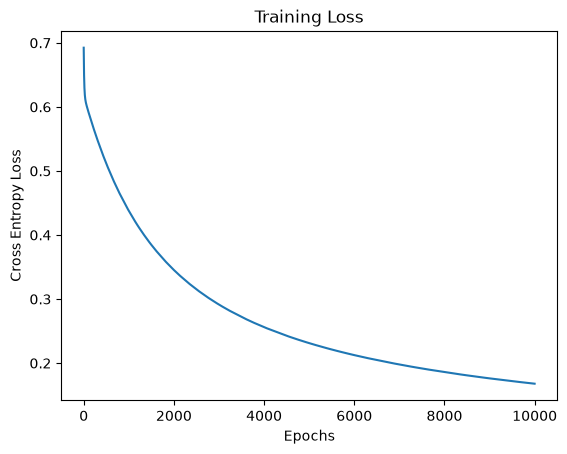

In [493]:
Logb = LogiRegression_b(study_df["hours_study"],study_df["Pass"])
Logb.train(10000, 0.001,1)

In [494]:
from sklearn.linear_model import LogisticRegression
logi_sk = LogisticRegression()
X = study_df[["hours_study"]]
y = study_df["Pass"]
logi_sk.fit(X, y)
print(f"for study hours 3.5 pass prob (sgd):{1 if Log.predict([[3.5]]) >= 0.5 else 0}")
print(f"for study hours 7.5 pass prob (sgd):{1 if Log.predict([[7.5]]) >= 0.5 else 0}")
print(f"for study hours 3.5 pass prob (bgd):{1 if Logb.predict([[3.5]]) >= 0.5 else 0}")
print(f"for study hours 7.5 pass prob (bgd):{1 if Logb.predict([[7.5]]) >= 0.5 else 0}")
print(f"for study hours 3.5 pass prob:{logi_sk.predict([[3.5]])}")
print(f"for study hours 7.5 pass prob:{logi_sk.predict([[7.5]])}")



for study hours 3.5 pass prob (sgd):0
for study hours 7.5 pass prob (sgd):1
for study hours 3.5 pass prob (bgd):0
for study hours 7.5 pass prob (bgd):1
for study hours 3.5 pass prob:[0]
for study hours 7.5 pass prob:[1]


/home/student/aiml_b/myenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/student/aiml_b/myenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [495]:
print(f"{'Method':<30}|{'weights':<15} | {'bias':<15} | {'cross entropy':<15} ")
print("-" * 70)
print(f"{'SGD_custom':<30} | {Log.weights[0]:<15.6f} | {Log.bias:<15.6f}| {np.mean(Log.loss_train[-1]):<15.6f}")
print(f"{'BGD_custom':<30} | {Logb.weights[0]:<15.6f} | {Logb.bias:<15.6f}| {np.mean(Logb.loss_train[-1]):<15.6f}")
print(f"{'SKlearn':<30} | {slr.coef_[0]:<15.6f} | {slr.intercept_:<15.6f}")

Method                        |weights         | bias            | cross entropy   
----------------------------------------------------------------------
SGD_custom                     | 1.204598        | -5.118808      | 0.167883       
BGD_custom                     | 1.203573        | -5.119873      | 0.167857       
SKlearn                        | 0.893369        | -0.000000      


Q3

In [496]:
class LogiRegression_3:

    def __init__(self, x, y):
        self.x = np.asarray(x)
        self.y = np.asarray(y)
        if self.x.ndim == 1:
            self.x = self.x.reshape(-1, 1)
        self.weights = np.zeros(self.x.shape[1])
        self.bias = 0

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def cross_entropy_loss(self, pred, actual):
        epsilon = 1e-15
        pred = np.clip(pred, epsilon, 1 - epsilon)
        loss = -np.mean(actual * np.log(pred) +(1 - actual) * np.log(1 - pred))
        return loss

    def predict(self, x):
        x = np.asarray(x)
        if x.ndim == 1:
            x = x.reshape(-1, 1)
        x = (x - self.x_mean) / self.x_std
        z = x @ self.weights + self.bias
        return self.sigmoid(z)

    def train(self, no_epoch, alpha):
        self.x_mean = np.mean(self.x, axis=0)
        self.x_std = np.std(self.x, axis=0)
        self.x = (self.x - self.x_mean) / self.x_std
        self.loss_train = []
        for i in tqdm(range(no_epoch)):
            epoch_pred = []
            for j in range(len(self.x)):
                z = np.dot(self.x[j], self.weights) + self.bias
                y_pred = self.sigmoid(z)
                error = y_pred - self.y[j]
                dw = self.x[j] * error
                db = error
                self.weights -= alpha * dw
                self.bias -= alpha * db
                epoch_pred.append(y_pred)
            epoch_pred = np.array(epoch_pred)
            loss = self.cross_entropy_loss(epoch_pred,self.y)
            self.loss_train.append(loss)

        plt.plot(self.loss_train)
        plt.xlabel("Epochs")
        plt.ylabel("Cross Entropy Loss")
        plt.title("Training Loss")
        plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]/tmp/ipykernel_9168/3025144041.py:11: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))
100%|██████████| 1000/1000 [00:00<00:00, 17850.99it/s]


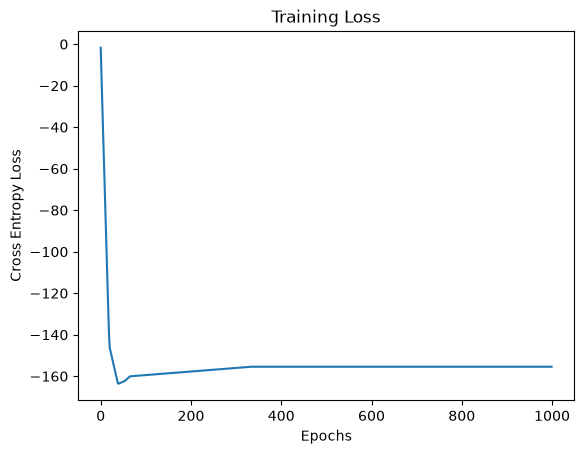

In [497]:
data = {
    "x1":[4,2,1,3,1,6],
    "x2":[1,8,0,2,4,7],
    "y":[2,-14,1,-1,-7,-8]
}
data = pd.DataFrame(data)
X = data[["x1", "x2"]].to_numpy()
y = data["y"].to_numpy()
Log = LogiRegression(X, y)
Log.train(1000, 0.001)

100%|██████████| 1000/1000 [00:00<00:00, 32672.03it/s]


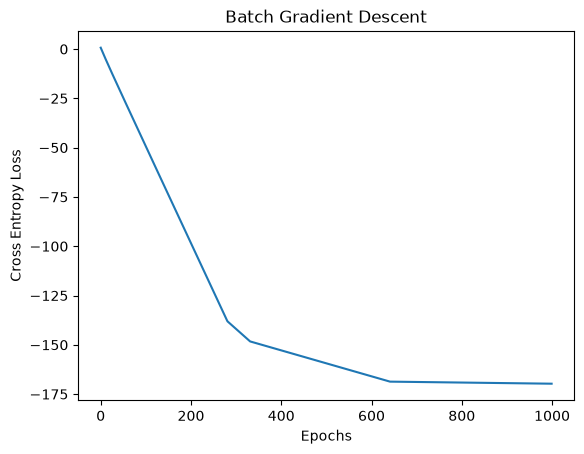

In [498]:
class LogiRegression_3_b:

    def __init__(self, x, y):
        self.x = np.asarray(x)
        self.y = np.asarray(y)
        if self.x.ndim == 1:
            self.x = self.x.reshape(-1, 1)
        self.weights = np.zeros(self.x.shape[1])
        self.bias = 0
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def cross_entropy_loss(self, pred, actual):
        epsilon = 1e-15
        pred = np.clip(pred, epsilon, 1 - epsilon)
        loss = -np.mean(actual * np.log(pred) +(1 - actual) * np.log(1 - pred))
        return loss

    def predict(self, x):
        x = np.asarray(x)
        if x.ndim == 1:
            x = x.reshape(-1, 1)
        x = (x - self.x_mean) / self.x_std
        z = x @ self.weights + self.bias
        return self.sigmoid(z)

    def train(self, no_epoch, alpha):
        self.x_mean = np.mean(self.x, axis=0)
        self.x_std = np.std(self.x, axis=0)
        self.x = (
            self.x - self.x_mean
        ) / self.x_std

        self.loss_train = []
        for i in tqdm(range(no_epoch)):
            z = self.x @ self.weights + self.bias
            y_pred = self.sigmoid(z)
            error = y_pred - self.y
            dw = (self.x.T @ error) / len(self.x)
            db = np.mean(error)
            self.weights -= alpha * dw
            self.bias -= alpha * db
            loss = self.cross_entropy_loss(y_pred,self.y)
            self.loss_train.append(loss)
        plt.plot(self.loss_train)
        plt.xlabel("Epochs")
        plt.ylabel("Cross Entropy Loss")
        plt.title("Batch Gradient Descent")
        plt.show()
        
Log = LogiRegression_3_b(X, y)
Log.train(1000, 0.01)

In [499]:
X = data[["x1", "x2"]]
y = data["y"]
logi_sk = LogisticRegression()
logi_sk.fit(X, y)
from sklearn.metrics import log_loss
y_prob = logi_sk.predict_proba(X)
loss = log_loss(y, y_prob)
print("Cross Entropy Loss:", loss)

Cross Entropy Loss: 0.5292086847318895
